# Modelling data - Version 9

This version includes all variables in the dataset. **Range: 2024-01-01 to 2025-06-30**

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


### Filter dataset by data range: 2025-01-01 to 2025-06-30

In [3]:
df['FECHA_HORA'] = pd.to_datetime(df['FECHA_HORA'])

start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2025-06-30')

df = df[(df['FECHA_HORA'] >= start_date) & (df['FECHA_HORA'] <= end_date)]

In [4]:
print(f"DF size after filtering by date range:  {df.shape}")

DF size after filtering by date range:  (13105, 26)


In [5]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
Index: 13105 entries, 35064 to 48168
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   FECHA_HORA             13105 non-null  datetime64[ns]
 1   YEAR                   13105 non-null  int64         
 2   MONTH                  13105 non-null  int64         
 3   DAY                    13105 non-null  int64         
 4   HORA                   13105 non-null  int64         
 5   PRECIO                 13105 non-null  float64       
 6   TERMICA                13105 non-null  float64       
 7   HIDRAULICA             13105 non-null  float64       
 8   SOLAR                  13105 non-null  float64       
 9   COGENERADOR            13105 non-null  float64       
 10  EOLICA                 13105 non-null  float64       
 11  NIVEL_ENSO             13105 non-null  float64       
 12  FUEL_CONS_ACPM         13105 non-null  float64

In [6]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA               0
YEAR                     0
MONTH                    0
DAY                      0
HORA                     0
PRECIO                   0
TERMICA                  0
HIDRAULICA               0
SOLAR                    0
COGENERADOR              0
EOLICA                   0
NIVEL_ENSO               0
FUEL_CONS_ACPM           0
FUEL_CONS_CARBON         0
FUEL_CONS_COMBUSTOLEO    0
FUEL_CONS_CRUDO          0
FUEL_CONS_GAS            0
FUEL_CONS_GAS_NI         0
FUEL_CONS_GLP            0
FUEL_COST_CARBON         0
FUEL_COST_GAS            0
FUEL_COST_GAS_NI         0
FUEL_COST_COMBUSTOLEO    0
IPC_VAR_MOM_PCT          0
IPP_VAR_PN_MOM_PCT       0
IPP_VAR_OI_MOM_PCT       0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [7]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [8]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (10484, 24)
Test set size: (2621, 24)


## Baseline Models

In [9]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [10]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -1.059784  249.728621  146854.908213  340.788288
Ridge             -1.054105  249.531801  146732.004234  340.604213
Lasso             -1.005587  249.042989  141915.735158  337.396465
ElasticNet        -1.470852  276.490493  155985.952550  354.219059
Decision Tree     -1.929427  250.890256  169160.091249  379.392493
Random Forest     -1.921819  265.265249  175213.197525  376.268954
Gradient Boosting -1.487687  254.148263  149505.102690  351.540116
SVR               -4.967469  392.302692  267216.595189  458.415416
KNN               -1.971020  303.339147  201034.997031  406.911647


In [11]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [12]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [13]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: -0.92418244264014
Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.3}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -1.4453095074700268
Best params: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 300}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -1.308029582658108
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


{'ElasticNet': {'best_score': -0.92418244264014,
  'best_params': {'model__alpha': 0.01, 'model__l1_ratio': 0.3}},
 'RandomForest': {'best_score': -1.4453095074700268,
  'best_params': {'model__max_depth': 5,
   'model__min_samples_split': 5,
   'model__n_estimators': 300}},
 'GradientBoosting': {'best_score': -1.308029582658108,
  'best_params': {'model__learning_rate': 0.1,
   'model__max_depth': 5,
   'model__n_estimators': 100}}}

In [14]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [15]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [16]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-1.286091,248.144477,155114.069596,349.368071
LightGBM,-1.557106,248.207395,158081.521160,358.369193
CatBoost,-1.500123,242.310148,146322.245856,336.116302


## Time Series Forecasting

### Splits the training and test sets as a time series

In [17]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (10484, 24)
Test set size: (2621, 24)


In [18]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -3.636716  376.790696  229342.505122  454.758591
Ridge             -3.607590  376.760242  231989.501517  453.449361
Lasso             -3.302590  352.369896  224493.452546  429.877350
ElasticNet        -1.724333  311.825558  175858.547144  386.997020
Decision Tree     -1.134992  248.333898  156428.703458  342.016542
Random Forest     -0.514026  224.229798  134404.001930  308.910987
Gradient Boosting -1.290610  229.041878  119708.818945  311.368901
SVR               -5.250510  378.037117  248200.090370  443.337744
KNN               -0.740073  286.269281  181728.250122  369.352386


### Prophet

In [19]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,FUEL_CONS_CARBON,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
35064,2024-01-01 00:00:00,251.91,1110705.18,6198917.64,0.0,16515.95,17292.56,3.0,339.0,123570.37016,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35065,2024-01-01 01:00:00,251.91,1112836.70,6074385.60,0.0,16155.37,8292.50,3.0,339.0,123570.37016,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35066,2024-01-01 02:00:00,251.91,1113080.66,5982315.72,0.0,16819.20,8737.69,3.0,339.0,123570.37016,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35067,2024-01-01 03:00:00,281.91,1110708.24,5841597.74,0.0,16702.69,10862.55,3.0,339.0,123570.37016,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35068,2024-01-01 04:00:00,281.91,899335.43,5949345.94,0.0,17741.16,8416.00,3.0,339.0,123570.37016,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81


10:27:47 - cmdstanpy - INFO - Chain [1] start processing
10:27:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 565.41, RMSE: 675.70, R2: -46.14


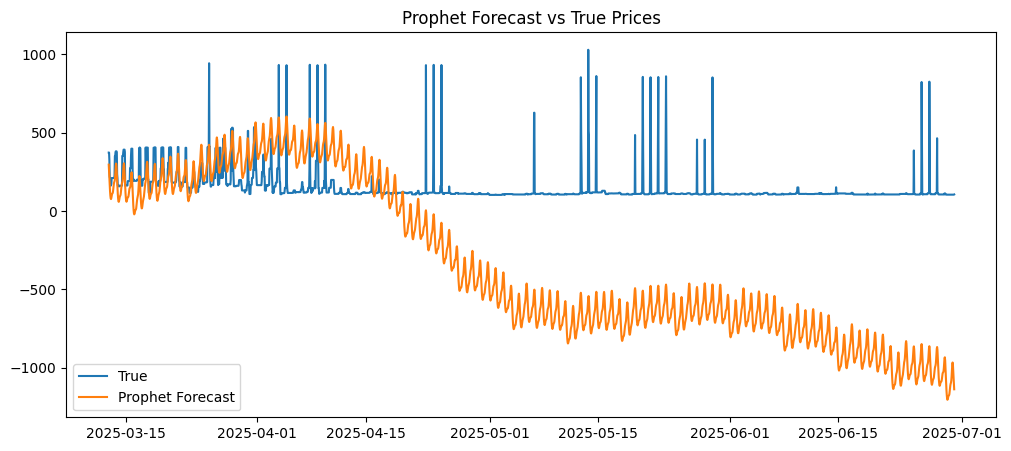

In [20]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 112.68, RMSE: 142.87, R2: -1.11


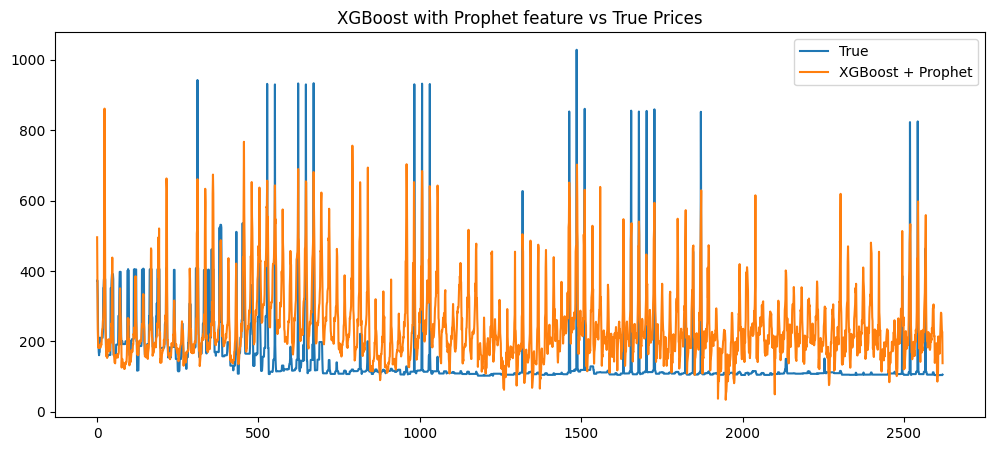

In [21]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [22]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [23]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
35088,2024,1,2,0,1285160.40,6061958.38,0.0,13510.68,10965.50,3.0,...,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91,251.91,251.91
35089,2024,1,2,1,1252557.85,5863196.52,0.0,12693.41,11778.13,3.0,...,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91,251.91
35090,2024,1,2,2,1210894.06,5740740.85,0.0,13030.87,12646.47,3.0,...,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91
35091,2024,1,2,3,1209337.44,5667752.92,0.0,13230.69,11186.29,3.0,...,152.91,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91
35092,2024,1,2,4,1032092.14,5902949.98,0.0,13449.09,11501.69,3.0,...,152.91,152.91,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 44.02, RMSE: 77.51, R2: 0.38


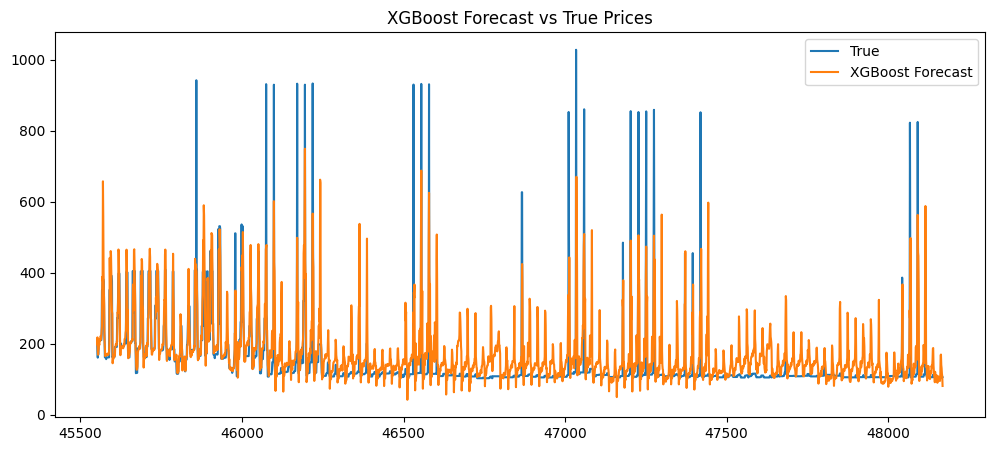

In [24]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [25]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [26]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 47
[LightGBM] [Info] Start training from score 637.692526
                MAE       RMSE        R2
XGBoost   52.599363  86.131576  0.230970
LightGBM  53.978762  80.218978  0.332928
CatBoost  37.810905  71.814937  0.465377


### Boosting with lags (tunning)

In [27]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [28]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-09-03 10:28:13,652] A new study created in memory with name: no-name-671319e6-dcb3-4375-a7ab-71853fee6c21


Running Optuna for XGBoost...


[I 2025-09-03 10:28:27,083] Trial 0 finished with value: 89.31823150754278 and parameters: {'n_estimators': 658, 'learning_rate': 0.11466579552826754, 'max_depth': 11, 'subsample': 0.8014468249638338, 'colsample_bytree': 0.9576826839226399, 'gamma': 0.256846446560241, 'reg_alpha': 0.3722888467151786, 'reg_lambda': 1.5596074873669208}. Best is trial 0 with value: 89.31823150754278.
[I 2025-09-03 10:28:34,830] Trial 1 finished with value: 99.21572606766759 and parameters: {'n_estimators': 394, 'learning_rate': 0.10070473151859234, 'max_depth': 10, 'subsample': 0.6729049212570173, 'colsample_bytree': 0.9324377395810659, 'gamma': 4.230885688671595, 'reg_alpha': 1.3438756127324436, 'reg_lambda': 3.687767385090555}. Best is trial 0 with value: 89.31823150754278.
[I 2025-09-03 10:28:55,238] Trial 2 finished with value: 82.8560343580244 and parameters: {'n_estimators': 659, 'learning_rate': 0.027546648283602135, 'max_depth': 11, 'subsample': 0.9904186886067616, 'colsample_bytree': 0.6977715882

Best params for XGBoost: {'n_estimators': 769, 'learning_rate': 0.01345651970573052, 'max_depth': 4, 'subsample': 0.8620389680288122, 'colsample_bytree': 0.8784374416121055, 'gamma': 4.577220972449305, 'reg_alpha': 0.27711486209837793, 'reg_lambda': 3.6044086127100496}
Best RMSE: 66.8011

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 47
[LightGBM] [Info] Start training from score 637.692526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

[I 2025-09-03 10:40:04,762] Trial 0 finished with value: 70.85613761826605 and parameters: {'n_estimators': 690, 'learning_rate': 0.0501928900690628, 'num_leaves': 282, 'max_depth': 12, 'min_child_samples': 45, 'subsample': 0.6527045008024592, 'colsample_bytree': 0.7034673443929217}. Best is trial 0 with value: 70.85613761826605.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-09-03 10:46:42,986] A new study created in memory with name: no-name-12e72b21-aad3-40f2-a054-a7dc256eff26


Best params for LightGBM: {'n_estimators': 1225, 'learning_rate': 0.01004267285998805, 'num_leaves': 295, 'max_depth': 6, 'min_child_samples': 24, 'subsample': 0.7347816015786319, 'colsample_bytree': 0.713637999080687}
Best RMSE: 67.0344

Running Optuna for CatBoost...


[I 2025-09-03 10:50:27,594] Trial 0 finished with value: 81.72158312991596 and parameters: {'iterations': 1090, 'learning_rate': 0.09706166432603056, 'depth': 10, 'l2_leaf_reg': 2.344538684360592, 'bagging_temperature': 0.5314188588778083}. Best is trial 0 with value: 81.72158312991596.
[I 2025-09-03 10:54:51,890] Trial 1 finished with value: 98.0393233837224 and parameters: {'iterations': 602, 'learning_rate': 0.24416458592576873, 'depth': 12, 'l2_leaf_reg': 2.1365694545152083, 'bagging_temperature': 0.9724704388477958}. Best is trial 0 with value: 81.72158312991596.
[I 2025-09-03 10:54:54,334] Trial 2 finished with value: 70.52430705463411 and parameters: {'iterations': 456, 'learning_rate': 0.17508550246732696, 'depth': 3, 'l2_leaf_reg': 8.712579295984678, 'bagging_temperature': 0.29285322571719064}. Best is trial 2 with value: 70.52430705463411.
[I 2025-09-03 10:55:06,152] Trial 3 finished with value: 116.46803653297349 and parameters: {'iterations': 230, 'learning_rate': 0.0110344

Best params for CatBoost: {'iterations': 519, 'learning_rate': 0.042883232189388956, 'depth': 6, 'l2_leaf_reg': 7.157295251285165, 'bagging_temperature': 0.22022969432931178}
Best RMSE: 67.7426

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 47
[LightGBM] [Info] Start training from score 637.692526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [29]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          769.0       0.013457        4.0   0.862039          0.878437   
LightGBM        1225.0       0.010043        6.0   0.734782          0.713638   
CatBoost           NaN       0.042883        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   4.577221   0.277115    3.604409         NaN                NaN   
LightGBM       NaN        NaN         NaN       295.0               24.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature  Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  66.801081  
LightGBM         NaN    NaN          NaN                  NaN  67.034363  
CatBoost       519.0    6.0     7.157295              0.22023  67.742642  
                MAE       

### Baseline models with lag

In [30]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae            mse        rmse
Linear Regression  0.714764   66.291054   14681.707404  110.829706
Ridge              0.716025   65.422228   14621.873043  110.443007
Lasso              0.754388   47.511770   12640.888653   98.511721
ElasticNet         0.756542   46.447900   12553.250513   97.933036
Decision Tree      0.340129  143.149092   91133.213930  229.244299
Random Forest      0.612620  107.346296   48767.019937  172.687019
Gradient Boosting  0.687775   97.385026   47745.502911  165.979126
SVR               -0.809700  287.110623  181211.912646  353.909746
KNN               -0.186375  222.856393  143432.852359  305.160100


### Baseline models (linear) with lag (tunning)

In [31]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [32]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.714764,66.291054,110.829706
Ridge,{'alpha': 100},0.734734,57.384936,104.929033
Lasso,{'alpha': 10},0.75867,45.45403,97.371083
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.9}",0.758634,45.494925,97.393947


In [33]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [34]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [35]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [36]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-09-03 11:30:52,242] A new study created in memory with name: no-name-840336bf-0aaa-4a85-aa81-a3225ecf3ba5
[I 2025-09-03 11:30:53,491] Trial 5 finished with value: 269.24182060963653 and parameters: {'max_depth': 2, 'min_samples_split': 11}. Best is trial 5 with value: 269.24182060963653.
[I 2025-09-03 11:30:53,649] Trial 10 finished with value: 269.24182060963653 and parameters: {'max_depth': 2, 'min_samples_split': 6}. Best is trial 5 with value: 269.24182060963653.
[I 2025-09-03 11:30:53,696] Trial 6 finished with value: 269.24182060963653 and parameters: {'max_depth': 2, 'min_samples_split': 12}. Best is trial 5 with value: 269.24182060963653.
[I 2025-09-03 11:30:55,086] Trial 17 finished with value: 217.45622782405925 and parameters: {'max_depth': 5, 'min_samples_split': 11}. Best is trial 17 with value: 217.45622782405925.
[I 2025-09-03 11:30:55,326] Trial 18 finished with value: 217.45622782405925 and parameters: {'max_depth': 5, 'min_samples_split': 9}. Best is trial 17 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 6, 'min_samples_split': 17}",0.467047,124.558263,217.15531
Random Forest,"{'n_estimators': 583, 'max_depth': 13, 'min_sa...",0.681647,95.134391,148.368263
Gradient Boosting,"{'n_estimators': 587, 'learning_rate': 0.00951...",0.680148,91.93311,150.144147


In [37]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 6, 'min_samples_split': 17},
  'R2': 0.46704738124094386,
  'MAE': 124.55826266102856,
  'RMSE': 217.15531001399185},
 'Random Forest': {'Best Params': {'n_estimators': 583,
   'max_depth': 13,
   'min_samples_split': 13,
   'max_features': 'sqrt'},
  'R2': 0.6816474528279148,
  'MAE': 95.13439086337249,
  'RMSE': 148.36826297995339},
 'Gradient Boosting': {'Best Params': {'n_estimators': 587,
   'learning_rate': 0.009510049012731654,
   'max_depth': 2,
   'subsample': 0.884518404278843},
  'R2': 0.680148184977952,
  'MAE': 91.93311022889262,
  'RMSE': 150.1441468203928}}

In [38]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [39]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [40]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [41]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [42]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                               r2          mae           mse         rmse
Extra Trees               0.64978    86.559225  4.414436e+04   148.157335
Hist Gradient Boosting    0.71591    80.177275  4.358162e+04   144.768932
MLP Regressor          -159.27771  2254.147914  7.672262e+06  2598.513075


<hr>

## Long short-term memory (LSTM)

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA', 'FUEL_CONS_ACPM', 'FUEL_CONS_CARBON', 'FUEL_CONS_COMBUSTOLEO', 'FUEL_CONS_CRUDO', 'FUEL_CONS_GAS', 'FUEL_CONS_GAS_NI', 'FUEL_CONS_GLP', 'FUEL_COST_CARBON', 'FUEL_COST_GAS', 'FUEL_COST_GAS_NI', 'FUEL_COST_COMBUSTOLEO', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [45]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
35064,2024,1,1,0,251.91,0.138481,0.493743,0.000000,0.106362,0.541970,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35065,2024,1,1,1,251.91,0.138947,0.478087,0.000000,0.103921,0.259897,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35066,2024,1,1,2,251.91,0.139001,0.466512,0.000000,0.108416,0.273850,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35067,2024,1,1,3,281.91,0.138481,0.448821,0.000000,0.107627,0.340445,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35068,2024,1,1,4,281.91,0.092202,0.462367,0.000000,0.114658,0.263768,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48164,2025,6,29,20,104.95,0.161700,0.779412,0.000402,0.692274,0.684903,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48165,2025,6,29,21,104.25,0.169859,0.749598,0.000000,0.701391,0.658193,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48166,2025,6,29,22,104.25,0.188852,0.694943,0.000000,0.684280,0.719394,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48167,2025,6,29,23,104.25,0.184977,0.645441,0.000000,0.686153,0.730356,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111


In [46]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48  # last 24 hours
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (13057, 48, 25)
y shape: (13057,)


In [47]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [48]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           78848     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 130369 (509.25 KB)
Trainable params: 130

In [49]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


131/131 [==============================] - 30s 181ms/step - loss: 640505.7500 - mae: 643.8027 - val_loss: 222776.0781 - val_mae: 390.1978
Epoch 2/50
131/131 [==============================] - 22s 168ms/step - loss: 491561.0625 - mae: 521.1432 - val_loss: 118469.1172 - val_mae: 267.3156
Epoch 3/50
131/131 [==============================] - 22s 169ms/step - loss: 332600.5938 - mae: 385.8516 - val_loss: 70914.5703 - val_mae: 227.1230
Epoch 4/50
131/131 [==============================] - 23s 173ms/step - loss: 230241.1094 - mae: 280.5852 - val_loss: 26549.0430 - val_mae: 112.3276
Epoch 5/50
131/131 [==============================] - 22s 170ms/step - loss: 157821.0312 - mae: 195.6816 - val_loss: 13490.6855 - val_mae: 75.6010
Epoch 6/50
131/131 [==============================] - 23s 176ms/step - loss: 116504.6641 - mae: 161.0930 - val_loss: 10599.9404 - val_mae: 64.3089
Epoch 7/50
131/131 [==============================] - 20s 152ms/step - loss: 89666.7344 - mae: 144.8205 - val_

In [50]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

82/82 [==============================] - 4s 36ms/step
R2: 0.17130723129141823, RMSE: 89.4847, MAE: 62.1141


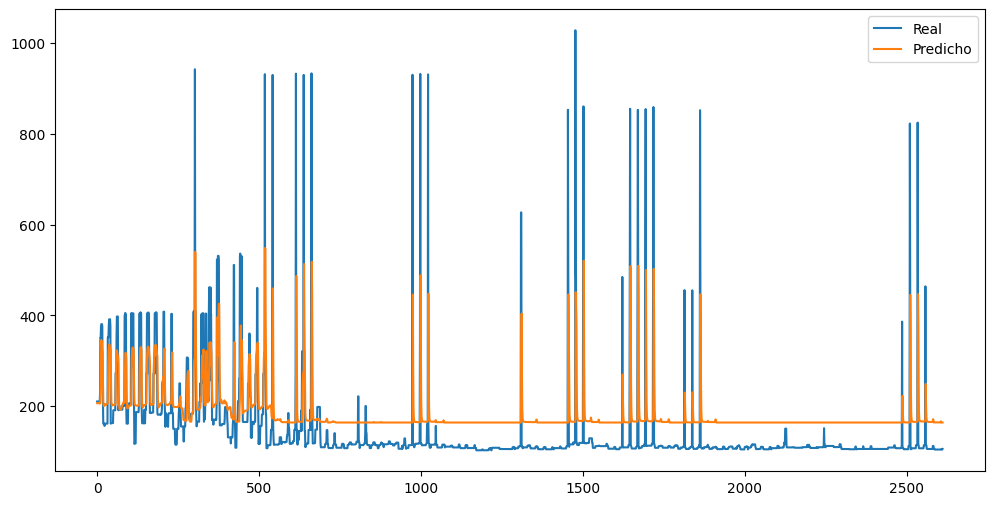

In [51]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()